In [75]:
%matplotlib widget
import csv
from collections import Counter
from datetime import datetime
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

PHASE_COLORS = {
    "forward": "#00A651",     # strong green
    "backward": "#0072CE",    # strong blue
    "optimizer": "#7B2CBF",   # strong purple
    "eval": "#2A9D8F",        # strong teal
    "checkpoint": "#C1121F",  # strong red
    "dataloader": "#FFB000",  # strong yellow/orange
    "idle": "#6C757D",        # strong gray
}

def resolve_csv_path(model_filename:str) -> Path:
    candidates = [
        Path.cwd() / "profiler" / f"{model_filename}.csv",
        Path.cwd().parent / "profiler" / f"{model_filename}.csv",
        Path(f"../profiler/{model_filename}.csv"),
        Path(f"profiler/{model_filename}.csv"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(f"Could not find profiler/{model_filename}.csv from the current notebook working directory")

def parse_float(value: str | None):
    if value in ("", None):
        return None
    return float(value)

def load_rows(csv_path: Path) -> list[dict]:
    with csv_path.open() as handle:
        raw_rows = list(csv.DictReader(handle))
    if not raw_rows:
        raise ValueError(f"no rows found in {csv_path}")

    timestamps = [datetime.fromisoformat(row["timestamp"]) for row in raw_rows]
    t0 = timestamps[0]
    inferred_intervals = []
    for idx, ts in enumerate(timestamps):
        if idx + 1 < len(timestamps):
            inferred_intervals.append((timestamps[idx + 1] - ts).total_seconds())
        elif idx > 0:
            inferred_intervals.append((ts - timestamps[idx - 1]).total_seconds())
        else:
            inferred_intervals.append(0.0)
    rows = []
    for raw, ts, inferred_interval in zip(raw_rows, timestamps, inferred_intervals):
        start_s = (ts - t0).total_seconds()
        interval_s = parse_float(raw.get("interval_s"))
        if interval_s is None:
            interval_s = max(inferred_interval, 0.0)
        end_s = start_s + interval_s
        rows.append(
            {
                "start_s": start_s,
                "end_s": end_s,
                "mid_s": start_s + interval_s / 2.0,
                "interval_s": interval_s,
                "step": int(raw["step"]),
                "phase": raw["phase"],
                "cpu": parse_float(raw["cpu_util_percent"]),
                "gpu": parse_float(raw["gpu_util_percent"]),
                "gpu_mem": parse_float(raw["gpu_mem_mb"]),
                "gpu_power": parse_float(raw.get("gpu_power_w")),
                "host_mem": parse_float(raw["host_mem_mb"]),
                "disk_read": parse_float(raw["disk_read_mb_s"]),
                "disk_write": parse_float(raw["disk_write_mb_s"]),
            }
        )
    return rows

def series(rows: list[dict], key: str) -> list[float]:
    return [float("nan") if row[key] is None else row[key] for row in rows]


In [76]:
def phase_durations(rows: list[dict]) -> Counter:
    durations = Counter()
    for row in rows:
        durations[row["phase"]] += row["interval_s"]
    return durations

def plot_summary(model_name:str ,ax, rows: list[dict], csv_path: Path) -> None:
    ax.axis("off")
    duration = max((row["end_s"] for row in rows), default=0.0)
    valid_steps = [row["step"] for row in rows if row["step"] >= 0]
    step_text = f"{min(valid_steps)}..{max(valid_steps)}" if valid_steps else "n/a"
    peak_gpu_mem = max((row["gpu_mem"] or 0.0) for row in rows)
    peak_gpu_power = max((row["gpu_power"] or 0.0) for row in rows)
    peak_host_mem = max((row["host_mem"] or 0.0) for row in rows)
    peak_disk_write = max((row["disk_write"] or 0.0) for row in rows)
    durations = phase_durations(rows)
    dominant_phase = durations.most_common(1)[0][0] if durations else "n/a"

    ax.text(0.01, 0.92, f"{model_name} Training Profile", fontsize=20, fontweight="bold", transform=ax.transAxes)
    ax.text(0.01, 0.77, str(csv_path), fontsize=10, color="#666666", transform=ax.transAxes)

    cards = [
        ("Samples", str(len(rows))),
        ("Duration", f"{duration:.1f}s"),
        ("Steps", step_text),
        ("Dominant Phase", dominant_phase),
        ("Peak GPU Mem", f"{peak_gpu_mem:.0f} MB"),
        ("Peak GPU Power", f"{peak_gpu_power:.1f} W"),
        ("Peak Host Mem", f"{peak_host_mem:.0f} MB"),
        ("Peak Disk Write", f"{peak_disk_write:.1f} MB/s"),
    ]

    x_positions = [0.01, 0.26, 0.51, 0.76]
    y_positions = [0.52, 0.20]
    idx = 0
    for y in y_positions:
        for x in x_positions:
            if idx >= len(cards):
                break
            label, value = cards[idx]
            ax.text(x, y, label, fontsize=10, color="#666666", transform=ax.transAxes)
            ax.text(x, y - 0.15, value, fontsize=14, fontweight="bold", transform=ax.transAxes)
            idx += 1

def plot_phase_timeline(ax, rows: list[dict]) -> None:
    duration = max((row["end_s"] for row in rows), default=1e-9)
    start_idx = 0
    for idx in range(1, len(rows) + 1):
        boundary = idx == len(rows) or rows[idx]["phase"] != rows[start_idx]["phase"]
        if not boundary:
            continue
        start_t = rows[start_idx]["start_s"]
        end_t = rows[idx - 1]["end_s"] if idx - 1 < len(rows) else duration
        color = PHASE_COLORS.get(rows[start_idx]["phase"], "#999999")
        ax.axvspan(start_t, end_t, ymin=0.25, ymax=0.75, color=color, ec="none")
        start_idx = idx

    handles = [Patch(facecolor=PHASE_COLORS[name], label=name) for name in PHASE_COLORS]
    ax.legend(handles=handles, loc="upper center", ncol=7, frameon=False, bbox_to_anchor=(0.5, 1.25))
    ax.set_title("Phase Timeline")
    ax.set_xlim(0, duration)
    ax.set_yticks([])
    ax.set_xlabel("Elapsed Time (s)")
    ax.grid(axis="x", color="#E5E7EB", linewidth=0.8)

def plot_line_panel(ax, rows: list[dict], items: list[tuple[str, str, str]], title: str, ylabel: str) -> None:
    x = [row["mid_s"] for row in rows]
    for label, key, color in items:
        ax.plot(x, series(rows, key), label=label, color=color, linewidth=1.8)
    ax.set_title(title)
    ax.set_xlabel("Elapsed Time (s)")
    ax.set_ylabel(ylabel)
    ax.grid(True, color="#E5E7EB", linewidth=0.8)
    ax.legend(frameon=False)

def shade_phase(ax, rows: list[dict], phase: str, color: str, alpha: float = 0.28) -> None:
    duration = max((row["end_s"] for row in rows), default=1e-9)
    start_idx = None
    added_label = False
    for idx, row in enumerate(rows):
        if row["phase"] == phase and start_idx is None:
            start_idx = idx
        elif row["phase"] != phase and start_idx is not None:
            start_t = rows[start_idx]["start_s"]
            end_t = rows[idx - 1]["end_s"]
            label = f"{phase} window" if not added_label else None
            ax.axvspan(start_t, end_t, color=color, alpha=alpha, ec="none", label=label)
            added_label = True
            start_idx = None
    if start_idx is not None:
        start_t = rows[start_idx]["start_s"]
        label = f"{phase} window" if not added_label else None
        ax.axvspan(start_t, duration, color=color, alpha=alpha, ec="none", label=label)

def shade_selected_phases(ax, rows: list[dict], phases: list[str], alpha: float = 0.22) -> None:
    for phase in phases:
        shade_phase(ax, rows, phase, PHASE_COLORS.get(phase, "#999999"), alpha=alpha)

def plot_phase_breakdown(ax, rows: list[dict]) -> None:
    durations = phase_durations(rows)
    total_duration = max(sum(durations.values()), 1e-9)
    phases = [name for name, _ in durations.most_common()]
    values = [100.0 * durations[name] / total_duration for name in phases]
    colors = [PHASE_COLORS.get(name, "#999999") for name in phases]
    bars = ax.barh(phases, values, color=colors)
    ax.invert_yaxis()
    ax.set_title("Phase Breakdown")
    ax.set_xlabel("Dataset Time (%)")
    ax.grid(axis="x", color="#E5E7EB", linewidth=0.8)
    ax.set_xlim(0, max(values, default=0.0) * 1.15 if values else 1.0)
    for bar, value in zip(bars, values):
        ax.text(value + 0.5, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center", ha="left", fontsize=10)

def plot_report(model_name:str, rows: list[dict], csv_path: Path):
    plt.style.use("default")
    fig = plt.figure(figsize=(16, 16), constrained_layout=True)
    gs = fig.add_gridspec(5, 2, height_ratios=[0.9, 0.8, 1.1, 1.1, 0.9])

    ax_summary = fig.add_subplot(gs[0, :])
    ax_timeline = fig.add_subplot(gs[1, :])
    ax_util = fig.add_subplot(gs[2, 0])
    ax_mem = fig.add_subplot(gs[2, 1])
    ax_disk = fig.add_subplot(gs[3, 0])
    ax_power = fig.add_subplot(gs[3, 1])
    ax_phase = fig.add_subplot(gs[4, :])

    plot_summary(model_name, ax_summary, rows, csv_path)
    plot_phase_timeline(ax_timeline, rows)
    plot_line_panel(
        ax_util,
        rows,
        [
            ("CPU util %", "cpu", "#059669"),
            ("GPU util %", "gpu", "#2563EB"),
        ],
        "Utilization",
        "Percent",
    )
    shade_phase(ax_util, rows, "checkpoint", PHASE_COLORS["checkpoint"], alpha=0.80)
    ax_util.legend(frameon=False)
    plot_line_panel(
        ax_mem,
        rows,
        [
            ("GPU mem MB", "gpu_mem", "#7C3AED"),
            ("Host mem MB", "host_mem", "#059669"),
        ],
        "Memory",
        "MB",
    )
    plot_line_panel(
        ax_disk,
        rows,
        [
            ("Disk read MB/s", "disk_read", "#2563EB"),
            ("Disk write MB/s", "disk_write", "#EA580C"),
        ],
        "Disk Throughput",
        "MB/s",
    )
    plot_line_panel(
        ax_power,
        rows,
        [
            ("GPU power W", "gpu_power", "#2563EB"),
        ],
        "GPU Power",
        "Watts",
    )
    shade_phase(ax_power, rows, "checkpoint", PHASE_COLORS["checkpoint"], alpha=0.80)
    ax_power.legend(frameon=False)
    plot_phase_breakdown(ax_phase, rows)

    fig.suptitle(f"{model_name} Profiler Report", fontsize=22, fontweight="bold")
    return fig


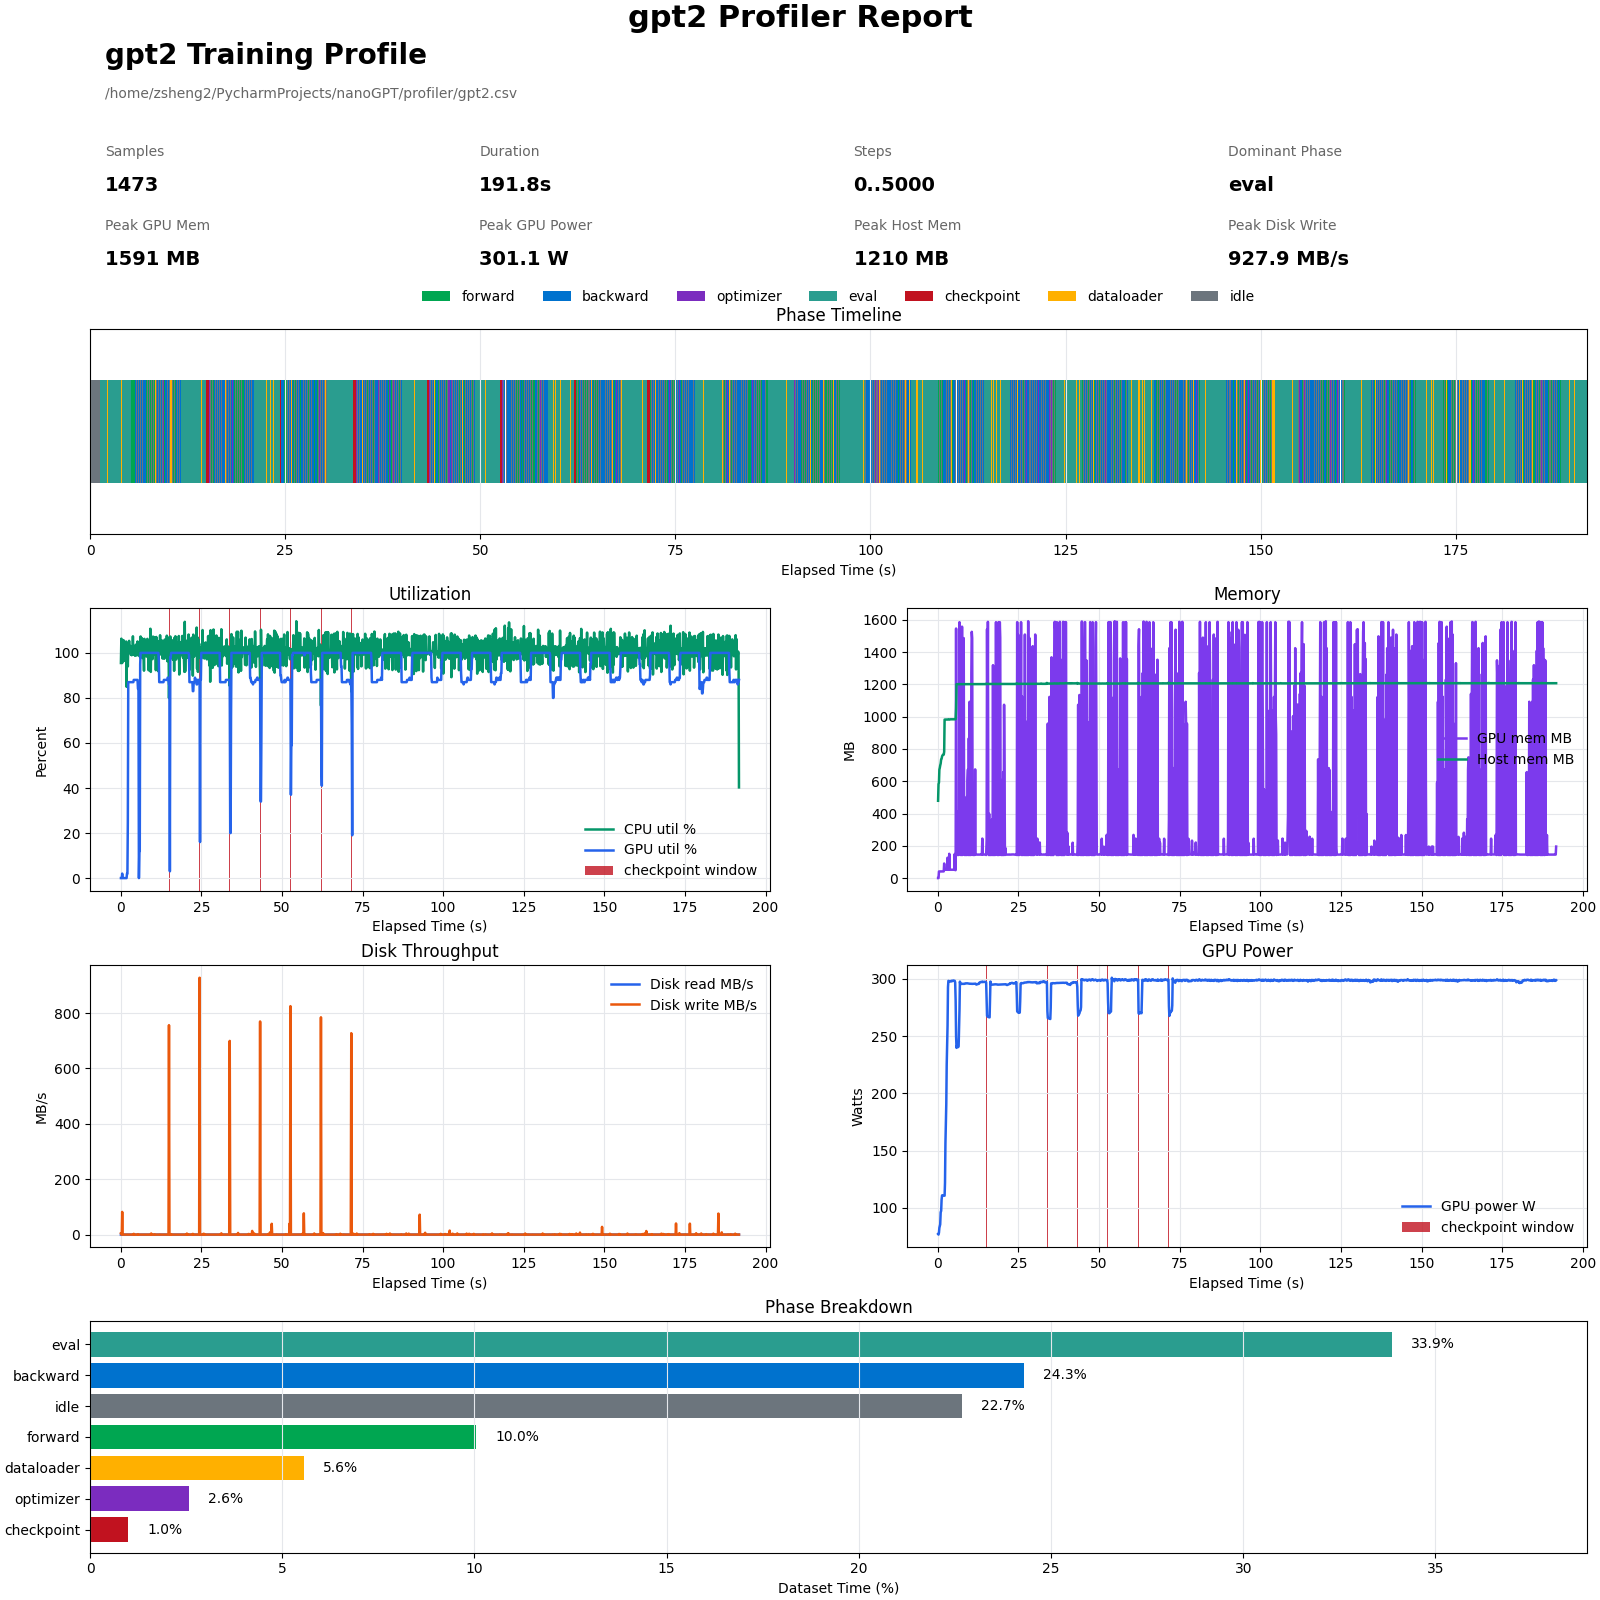

In [77]:
#gpt2
csv_path_gpt2 = resolve_csv_path("gpt2")
rows_gpt2 = load_rows(csv_path_gpt2)
fig_gpt2 = plot_report("gpt2",rows_gpt2, csv_path_gpt2)
fig_gpt2.canvas.toolbar_visible = True
fig_gpt2.canvas.header_visible = False
fig_gpt2.canvas.resizable = True
fig_gpt2.canvas.capture_scroll = True
display(fig_gpt2.canvas)
#plt.close(fig_gpt2)
output_path_gpt2 = csv_path_gpt2.with_suffix('.png')
fig_gpt2.savefig(output_path_gpt2, dpi=180, bbox_inches='tight')
print(output_path_gpt2)

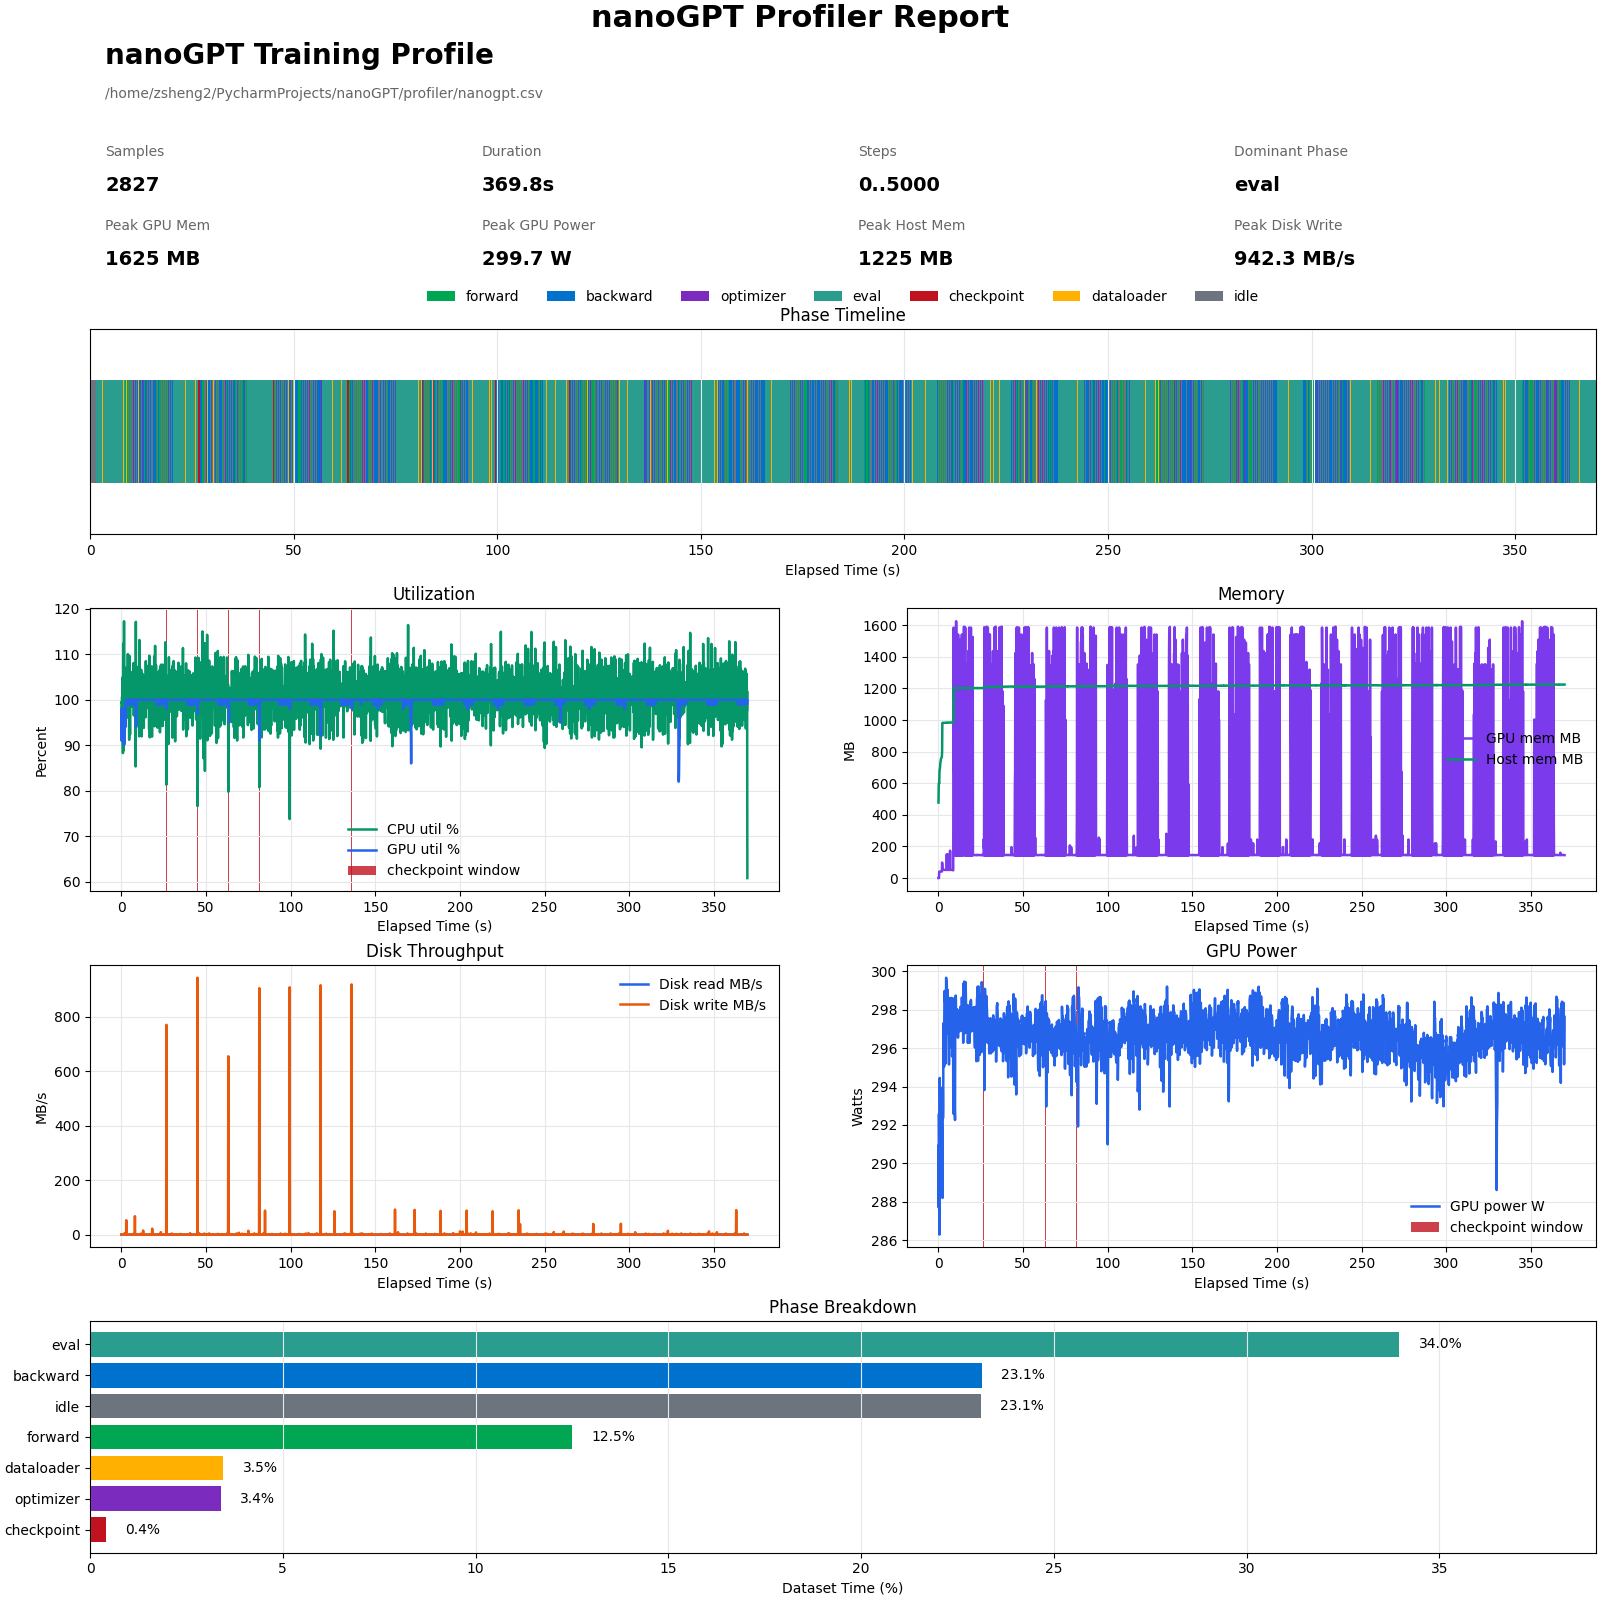

In [78]:
#nanogpt
csv_path_nanogpt = resolve_csv_path("nanogpt")
rows_nanogpt = load_rows(csv_path_nanogpt)
fig_nanogpt = plot_report("nanoGPT",rows_nanogpt, csv_path_nanogpt)
fig_nanogpt.canvas.toolbar_visible = True
fig_nanogpt.canvas.header_visible = False
fig_nanogpt.canvas.resizable = True
fig_nanogpt.canvas.capture_scroll = True
display(fig_nanogpt.canvas)
#plt.close(fig_nanogpt)
output_path_nanogpt = csv_path_nanogpt.with_suffix('.png')
fig_nanogpt.savefig(output_path_nanogpt, dpi=180, bbox_inches='tight')
print(output_path_nanogpt)